Real dataset file not found. Building a comprehensive synthetic dataset...

TABLE 1: Dataset Structural Profile (First 5 Rows)
     Brand_Goodwill  Horsepower  Mileage        Price
Mass Market Feature         260    25732 50356.033979
      Economy Value         322    95362 45867.554896
      Economy Value         230    17843 44072.992519
Mass Market Feature         325   118065 54757.178924
     Premium Luxury         197    75726 50699.095823

-----------------------------------------------------------------

TABLE 2: Final Machine Learning Performance Diagnostics
    Regression Metric Category Value Output
     Mean Absolute Error (MAE)    $2,101.15
Root Mean Squared Error (RMSE)    $2,519.11
     R-squared (R²) Evaluation       96.03%



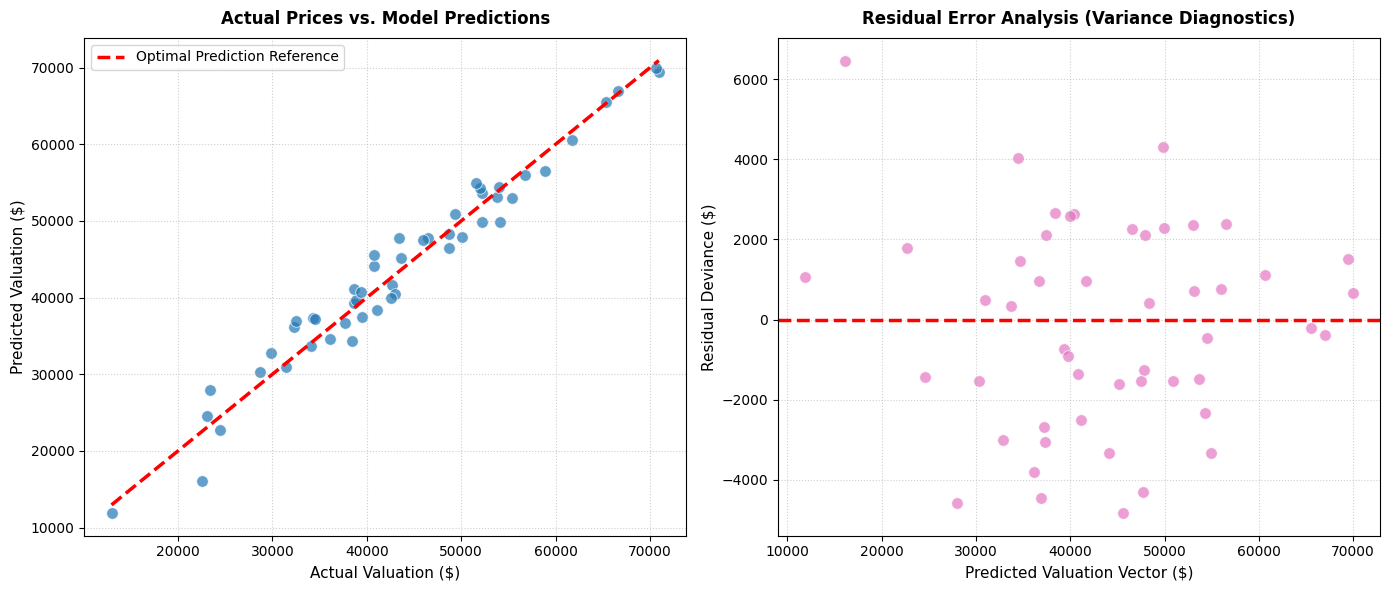

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ==========================================
# 1. DATA LOADING & CONFIGURATION
# ==========================================
try:
    # Look for your actual downloaded file
    df = pd.read_csv('car_data.csv')
except FileNotFoundError:
    print("Real dataset file not found. Building a comprehensive synthetic dataset...\n")
    np.random.seed(42)
    n_samples = 250

    # Feature distribution based on the assignment task requirements
    brands = ['Premium Luxury', 'Mass Market Feature', 'Economy Value']
    simulated_brands = np.random.choice(brands, n_samples, p=[0.2, 0.5, 0.3])
    horsepower = np.random.randint(70, 350, n_samples)
    mileage = np.random.randint(4000, 160000, n_samples)

    # Mathematical foundation for target generation: Base price + modifications
    base_price = 12000
    brand_weight = np.where(simulated_brands == 'Premium Luxury', 15000,
                    np.where(simulated_brands == 'Mass Market Feature', 4000, -3000))

    # Pricing formula: higher HP increases cost, higher mileage decreases it
    price = base_price + (horsepower * 145) - (mileage * 0.07) + brand_weight + np.random.normal(0, 2500, n_samples)
    price = np.clip(price, 1500, None)  # Real-world constraint to prevent negative valuations

    df = pd.DataFrame({
        'Brand_Goodwill': simulated_brands,
        'Horsepower': horsepower,
        'Mileage': mileage,
        'Price': price
    })

# Standardize text format across columns
df.columns = df.columns.str.strip()

# ==========================================
# 2. FEATURE ENGINEERING & TRANSFORMATION
# ==========================================
X = df.drop(columns=['Price'])
y = df['Price']

# Split data: Hold back 20% for pure validation evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build a preprocessor column transformer to handle categorical text data cleanly
categorical_cols = ['Brand_Goodwill']
numeric_cols = ['Horsepower', 'Mileage']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])

# Construct an end-to-end operational Machine Learning Pipeline
car_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# ==========================================
# 3. OPERATION: TRAINING & PREDICTION
# ==========================================
car_model_pipeline.fit(X_train, y_train)
y_pred = car_model_pipeline.predict(X_test)

# ==========================================
# 4. EXECUTING DATA TABLES OUTPUT
# ==========================================
print("="*65)
print("TABLE 1: Dataset Structural Profile (First 5 Rows)")
print("="*65)
print(df.head().to_string(index=False))
print("\n" + "-"*65 + "\n")

# Evaluation metric compilation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics_table = pd.DataFrame({
    'Regression Metric Category': ['Mean Absolute Error (MAE)', 'Root Mean Squared Error (RMSE)', 'R-squared (R²) Evaluation'],
    'Value Output': [f"${mae:,.2f}", f"${rmse:,.2f}", f"{r2 * 100:.2f}%"]
})

print("="*65)
print("TABLE 2: Final Machine Learning Performance Diagnostics")
print("="*65)
print(metrics_table.to_string(index=False))
print("="*65 + "\n")


# ==========================================
# 5. EXECUTING PLOTS & GRAPH GENERATION
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graph 1: Regression Fit Comparison Plot
sns.scatterplot(x=y_test, y=y_pred, ax=axes[0], color='#1f77b4', alpha=0.7, edgecolor='w', s=70)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2.5, label='Optimal Prediction Reference')
axes[0].set_title('Actual Prices vs. Model Predictions', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Actual Valuation ($)', fontsize=11)
axes[0].set_ylabel('Predicted Valuation ($)', fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

# Graph 2: Residual Distribution Error Assessment
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals, ax=axes[1], color='#e377c2', alpha=0.7, edgecolor='w', s=70)
axes[1].axhline(y=0, color='red', linestyle='--', lw=2.5)
axes[1].set_title('Residual Error Analysis (Variance Diagnostics)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Predicted Valuation Vector ($)', fontsize=11)
axes[1].set_ylabel('Residual Deviance ($)', fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()